In [191]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,classification_report, confusion_matrix)

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/train.csv')
df.head()

,carrier,weathertype,huboriginsize,origin,destination,distance,weatherspeed,gustsummary,isweekend,isholiday,taxiout,taxiin,scheduledelapsed,arrprevdelay,depvisibility,temperature,month,hour,depdelay
0,A,Storm,M,CJU,TAE,550.746267,9.692544,0,1,0,22.237891,14.428829,120.611079,11.020420,8.700310,4.188612,3,8,10.69
1,C,Clear,L,CJU,GMP,847.963857,13.929117,0,1,0,23.465180,9.171619,151.342918,-15.468226,8.282075,14.171997,6,15,8.28
2,D,Storm,M,GMP,GMP,676.198033,11.228448,1,1,0,21.909417,6.658539,102.918228,-21.276137,12.229477,-1.054223,7,10,14.43
3,A,Clear,M,GMP,CJU,725.841216,8.090339,0,0,0,15.231211,6.978108,82.059522,1.395369,6.835633,17.506742,6,5,-2.21
4,A,Fog,S,PUS,CJU,593.495394,18.568015,0,0,0,28.337872,7.469045,85.880826,13.455579,8.149568,18.954028,12,17,25.67


##### 1. 결측치를 확인하고 적절한 처리 방안 제시 뒤 적용

In [3]:
display(df.isna().sum().to_frame().T)

,carrier,weathertype,huboriginsize,origin,destination,distance,weatherspeed,gustsummary,isweekend,isholiday,taxiout,taxiin,scheduledelapsed,arrprevdelay,depvisibility,temperature,month,hour,depdelay
0,0,0,0,0,0,0,91,0,0,0,101,0,0,0,97,88,0,0,0


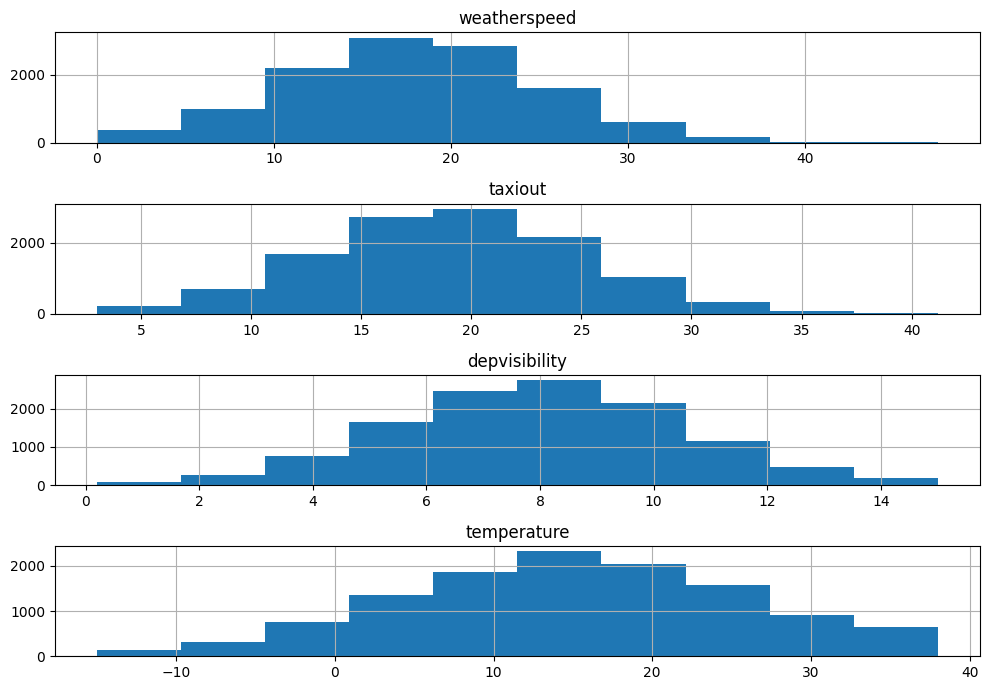

In [4]:
na_cols = df.columns[df.isna().any()].to_list()

fig, axes  = plt.subplots(4,1, figsize = (10, 7))

for axes , col in zip(axes.flatten(), na_cols) : 
    df[col].hist(ax = axes)
    axes.set_title(col)

plt.tight_layout()
plt.show()  

In [5]:
# 중의수 처리
m_df = df.copy()
m_df[na_cols] = SimpleImputer(strategy = 'median').fit_transform(m_df[na_cols]) 

m_df.isna().sum().to_frame().T

,carrier,weathertype,huboriginsize,origin,destination,distance,weatherspeed,gustsummary,isweekend,isholiday,taxiout,taxiin,scheduledelapsed,arrprevdelay,depvisibility,temperature,month,hour,depdelay
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##### 2.Depdelay > 0 이면 1, 아니면 0 delay_idx 생성

In [6]:
m_df['delay_idx'] = m_df['depdelay'].apply(lambda x : 1 if x > 0 else 0)

##### 3. 연속형, 범주형 변수를 구분하고, 종속변수와 독립 변수의 연관성 및 독립변수간 연관성탐색

In [7]:
# 연속형 변수와 범주형 변수 구분하기 
num_cols = []
cat_cols = []
for col in m_df.columns.difference(['carrier','delay_idx']) : 
    if m_df[col].nunique() <= 24 : 
        cat_cols.append(col)
    else : 
        num_cols.append(col)

cat_cols.append('delay_idx')
print('연속형 변수')
print(num_cols)
print('')
print('범주형 변수')
print(cat_cols)

연속형 변수
['arrprevdelay', 'depdelay', 'depvisibility', 'distance', 'scheduledelapsed', 'taxiin', 'taxiout', 'temperature', 'weatherspeed']

범주형 변수
['destination', 'gustsummary', 'hour', 'huboriginsize', 'isholiday', 'isweekend', 'month', 'origin', 'weathertype', 'delay_idx']


In [8]:
# 종속변수와 독립 변수의 연관성 
m_df['carrier'].value_counts() ## 5개 -> f_oneway 

# 종속변수와 연속변수의 연관성 
f = []
for col in num_cols : 
    groups = [group[col] for name, group in m_df.groupby('carrier')]
    s, p = stats.f_oneway(*groups)
    d = '유의하다' if p < 0.05 else '유의하지 않다'
    f.append({
        'Col' : col, 
        'P_value' : p, 
        'Decision' : d
    })

display(pd.DataFrame(f).sort_values(by = 'P_value', ascending = True))

chi = []
for col in cat_cols : 
    tab = pd.crosstab(m_df['carrier'], m_df[col])
    s, p , _ , _= stats.chi2_contingency(tab)
    d = '유의하다' if p < 0.05 else '유의하지 않다'
    chi.append({
        'Col' : col, 
        'P_value' : p, 
        'Decision' : d
    })

display(pd.DataFrame(chi).sort_values(by = 'P_value', ascending = True))


,Col,P_value,Decision
1,depdelay,5.825428e-26,유의하다
6,taxiout,6.926690e-02,유의하지 않다
0,arrprevdelay,9.319380e-02,유의하지 않다
5,taxiin,3.839700e-01,유의하지 않다
4,scheduledelapsed,6.070582e-01,유의하지 않다
7,temperature,6.808163e-01,유의하지 않다
8,weatherspeed,7.224881e-01,유의하지 않다
3,distance,8.012526e-01,유의하지 않다
2,depvisibility,8.653986e-01,유의하지 않다


,Col,P_value,Decision
9,delay_idx,3.343243e-15,유의하다
7,origin,7.416988e-02,유의하지 않다
0,destination,7.618513e-02,유의하지 않다
3,huboriginsize,9.983097e-02,유의하지 않다
8,weathertype,2.110087e-01,유의하지 않다
4,isholiday,2.429274e-01,유의하지 않다
5,isweekend,2.740044e-01,유의하지 않다
6,month,3.880896e-01,유의하지 않다
2,hour,5.040106e-01,유의하지 않다
1,gustsummary,6.955634e-01,유의하지 않다


In [9]:
from itertools import combinations
# 독립변수간 연관성 
# 1) 연속변수간 VIF- Corr 
num_df = m_df[num_cols]

cor = []
for v1 , v2 in list(combinations(num_df.columns, 2)) : 
    s, p = stats.pearsonr(num_df[v1], num_df[v2])
    d = '유의하다' if p < 0.05 else '유의하지 않다' 
    cor.append([v1,v2,p, d])
cor_df = pd.DataFrame(cor, columns = ['V1','V2','P_value','Decision'])
print(cor_df[cor_df['Decision'] == '유의하다']) 

              V1             V2        P_value Decision
0   arrprevdelay       depdelay   1.166504e-90     유의하다
8       depdelay  depvisibility   6.616590e-21     유의하다
9       depdelay       distance   0.000000e+00     유의하다
12      depdelay        taxiout   2.131376e-41     유의하다
14      depdelay   weatherspeed  9.306518e-240     유의하다


In [10]:
# 2) 독립변수간 Chi2_
cat_df = m_df[cat_cols]

cat = []
for v1 , v2 in list(combinations(cat_df.columns, 2)) : 
    tab = pd.crosstab(cat_df[v1], cat_df[v2])
    s, p, _, _ = stats.chi2_contingency(tab)
    d = '유의하다' if p < 0.05 else '유의하지 않다'
    cat.append([v1,v2,p, d])
cat_df = pd.DataFrame(cat, columns = ['V1','V2','P_value','Decision'])
print(cat_df[cat_df['Decision'] == '유의하다']) 

               V1         V2        P_value Decision
29  huboriginsize  delay_idx   9.416363e-20     유의하다
31      isholiday      month   6.192088e-03     유의하다
34      isholiday  delay_idx   1.468963e-04     유의하다
38      isweekend  delay_idx   5.490587e-05     유의하다
44    weathertype  delay_idx  6.721856e-161     유의하다


In [11]:
# 3) 범주 + 연속 
ff = []
for cat in cat_cols : 
    for num in num_cols : 
        g = [group[num] for name, group in m_df.groupby(cat)]
        s, p = stats.f_oneway(*g)
        d = '유의하다' if p < 0.05 else '유의하지 않다'
        ff.append([cat, num, p, d])
ff = pd.DataFrame(ff, columns = ['Cat','Num','P_value','Decision'])
print(ff[ff['Decision'] == '유의하다']) 

              Cat            Num        P_value Decision
28  huboriginsize       depdelay   1.207689e-31     유의하다
37      isholiday       depdelay   3.071460e-06     유의하다
46      isweekend       depdelay   2.473794e-08     유의하다
73    weathertype       depdelay  4.626106e-266     유의하다
81      delay_idx   arrprevdelay   1.998103e-55     유의하다
82      delay_idx       depdelay   0.000000e+00     유의하다
83      delay_idx  depvisibility   1.403739e-12     유의하다
84      delay_idx       distance  1.156682e-215     유의하다
87      delay_idx        taxiout   3.166041e-23     유의하다
89      delay_idx   weatherspeed  1.282960e-146     유의하다


##### 4) EDA를 바탕으로 종속변수에 영향을 줄 것이라고 판단되는 연속형 변수 3개와 범주형 변수 3개를 제시

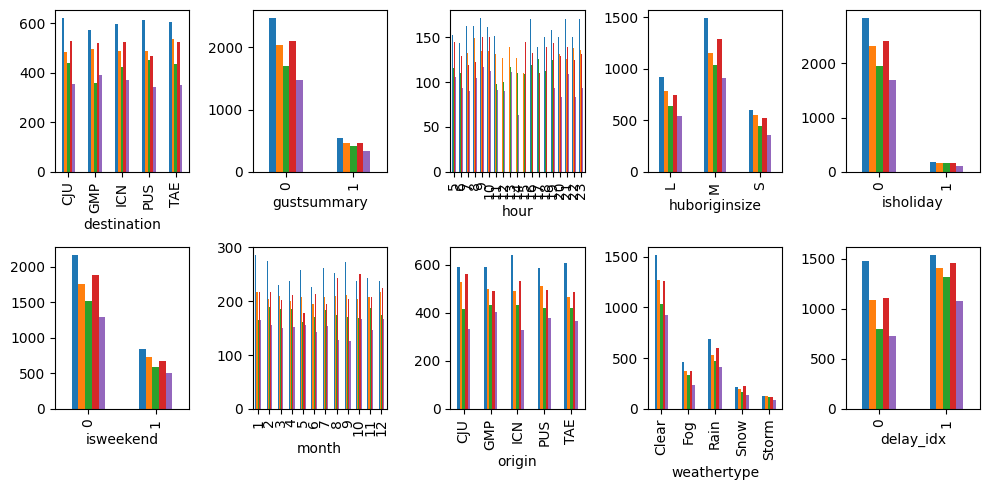


destination 
huboriginsize
weathertype



In [15]:
fig, axes = plt.subplots(2, 5, figsize = (10, 5)) 

for axes, col in zip(axes.flatten(), cat_cols) : 
    tab = pd.crosstab(m_df[col] , m_df['carrier'])
    tab.plot(kind = 'bar', ax = axes, legend=False)
    
plt.tight_layout()
plt.show()

print('''
destination 
huboriginsize
weathertype
''')

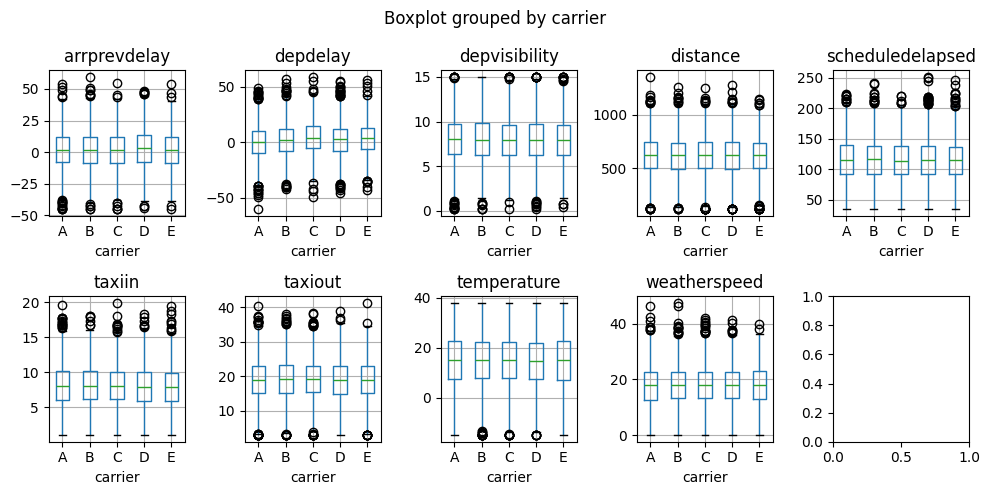

In [13]:
fig, axes = plt.subplots(2, 5, figsize = (10, 5)) 

for axes, col in zip(axes.flatten(), num_cols) : 
    m_df.boxplot(column = col, by = 'carrier' , ax = axes)
    
plt.tight_layout()
plt.show()

1-5 단일 분류 모형 1개와 앙상블 모형 1개를 학습, 전처리 및 변수 변환 여부를 설명한 후 성능지표 2개 이상과 변수 중요도를 제시

In [21]:
# 전처리 및 변수 변환 여부 

# 1-4에서 선택한 변수를 선정
selected_col = ['destination', 'huboriginsize' , 'weathertype' ,'arrprevdelay' , 'distance' ,'scheduledelapsed' ,'carrier']

model_df = m_df[selected_col]

# 전처리 
# 범주형 - One-Hot 
# 연속형 - 스케일링

clean_df = pd.DataFrame()
for col in model_df.columns : 
    if model_df[col].dtype == 'object' : 
        la = LabelEncoder()
        clean_df[col] = la.fit_transform(model_df[col])
    else : 
        ss = StandardScaler()
        clean_df[col] = ss.fit_transform(model_df[[col]]).flatten()


clean_df.head()


,destination,huboriginsize,weathertype,arrprevdelay,distance,scheduledelapsed,carrier
0,4,1,4,0.606127,-0.391612,0.155006,0
1,1,0,0,-1.178540,1.270420,1.048088,2
2,1,1,4,-1.569847,0.309911,-0.359158,3
3,0,1,0,-0.042359,0.587514,-0.965322,0
4,0,2,1,0.770196,-0.152560,-0.854273,0


In [25]:
X = clean_df.drop(columns = 'carrier')
y = clean_df['carrier']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify= y)

In [27]:
# 단일 분류 모형 1개와 앙상블 모형 1개를 학습
# Decision Tree , Random-Forest

def eval_model(name, model) : 
    model.fit(x_train, y_train) 
    pred = model.predict(x_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')

    return name, acc, f1

res = []
mlst = []
for name, model in [['Decision_Tree', DecisionTreeClassifier(max_depth= 5, random_state= 42)], 
                    ['Random_Forest' , RandomForestClassifier(n_estimators=5, random_state= 42) ]] : 
    name, acc, f1 = eval_model(name, model)
    res.append([name, acc, f1]) 
    mlst.append([name, model]) 

print(pd.DataFrame(res))

               0         1         2
0  Decision_Tree  0.253611  0.099884
1  Random_Forest  0.216111  0.196798


Decision_Tree
arrprevdelay    0.565232
distance        0.190829
dtype: float64
Random_Forest
scheduledelapsed    0.276279
arrprevdelay        0.275515
dtype: float64


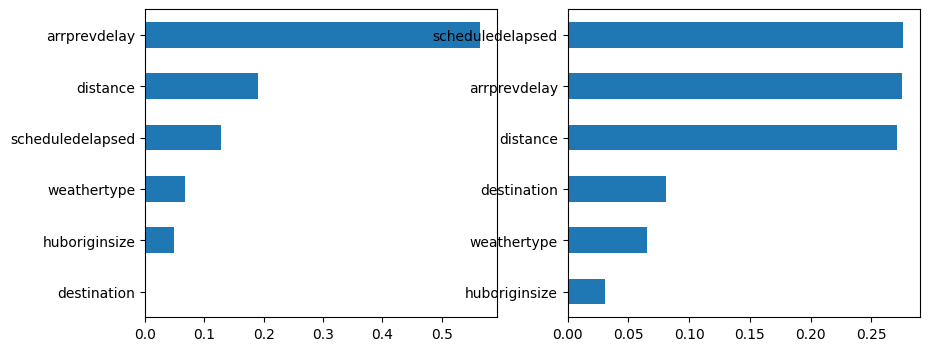

In [41]:
fig, axes = plt.subplots(1,2, figsize = (10, 4))

for axes, (name, model) in zip(axes, mlst) : 
    imp = pd.Series(model.feature_importances_,
                    index = model.feature_names_in_).sort_values(ascending = True)

    imp.plot(kind = 'barh', ax = axes)
    print(name)
    print(imp.sort_values(ascending = False).head(2))

plt.show()

#### 2.ML 
- 2-1 Passenger.csv의 hour를 long형태로 바꾸고, 승차와 하차를 합산한 count를 생성
- 2-2 날짜를 YYYY-MM-DD HH:00:00형식의 datetime으로 변환 

In [42]:
p= pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/passenger.csv')
p.head()

,date,ride_type,line,station,lat,lon,hour_05,hour_06,hour_07,hour_08,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,2022-01-01,승차,1호선,서울역,37.553150,126.972533,322,614,1014.0,2372,...,3862,4591,4154,5913,3889.0,3519,2765,3127,3075,2854
1,2022-01-01,하차,1호선,서울역,37.553150,126.972533,297,1511,1800.0,2462,...,4534,5471,4572,4903,4075.0,3296,2484,2985,2262,1457
2,2022-01-01,승차,1호선,시청역,37.563590,126.975407,61,94,142.0,236,...,1032,1043,1223,1473,1167.0,1121,1109,1055,727,213
3,2022-01-01,하차,1호선,시청역,37.563590,126.975407,74,688,471.0,725,...,1101,909,1078,821,728.0,350,308,255,220,211
4,2022-01-01,승차,2호선,강남역,37.497958,127.027539,317,480,566.0,846,...,5030,5297,6462,6065,3630.0,3665,3742,3970,5011,2129


In [50]:
pivot_df = p.melt(id_vars = ['date','ride_type','line','station','lat', 'lon'] , 
      var_name = 'hour',
      value_name = '승하차').pivot_table(index = ['date', 'line','station','lat', 'lon','hour'] , 
                                        columns = 'ride_type',
                                        values = '승하차').reset_index()

In [56]:
pivot_df.columns.name =  ''
pivot_df['date']  = pd.to_datetime(pivot_df['date'] +' ' +  pivot_df['hour'].str.split('_').str[1] )

In [59]:
pivot_df['count'] = pivot_df['승차'] + pivot_df['하차']
pivot_df.head()

,date,line,station,lat,lon,hour,승차,하차,count
0,2022-01-01 05:00:00,1호선,서울역,37.55315,126.972533,hour_05,322.0,297.0,619.0
1,2022-01-01 06:00:00,1호선,서울역,37.55315,126.972533,hour_06,614.0,1511.0,2125.0
2,2022-01-01 07:00:00,1호선,서울역,37.55315,126.972533,hour_07,1014.0,1800.0,2814.0
3,2022-01-01 08:00:00,1호선,서울역,37.55315,126.972533,hour_08,2372.0,2462.0,4834.0
4,2022-01-01 09:00:00,1호선,서울역,37.55315,126.972533,hour_09,3683.0,3130.0,6813.0


2-3 weather 에서 3개의 관측소와 각 지하철역의 위도 경도를 이용해 역-관측소 조합의 하버사인 만들어서 distance_km

In [60]:
w= pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/weather.csv')
w.head()

,datetime,site,site_lat,site_lon,temperature,humidity,windspeed,rainfall
0,2022-01-01 05:00:00,강남,37.5172,127.0473,-9.1,53.0,3.2,0.0
1,2022-01-01 06:00:00,강남,37.5172,127.0473,-9.1,52.0,1.6,0.0
2,2022-01-01 07:00:00,강남,37.5172,127.0473,-8.9,50.0,0.8,0.0
3,2022-01-01 08:00:00,강남,37.5172,127.0473,-8.6,48.0,2.7,0.0
4,2022-01-01 09:00:00,강남,37.5172,127.0473,-9.3,55.0,6.1,0.0


In [65]:
# 관측소 - w
site = w.groupby('site')[['site_lat','site_lon']].min().reset_index()
site

,site,site_lat,site_lon
0,강남,37.5172,127.0473
1,광진,37.5384,127.0822
2,남현,37.4740,126.9789
3,용산,37.5323,126.9900


In [66]:
# 역 
station = pivot_df.groupby('station')[['lat','lon']].min().reset_index()
station

,station,lat,lon
0,강남역,37.497958,127.027539
1,광화문역,37.570545,126.976568
2,사당역,37.476536,126.981631
3,삼성역,37.508827,127.063203
4,서울역,37.553150,126.972533
5,시청역,37.563590,126.975407
6,이태원역,37.534485,126.994369


In [89]:
# 모든 역 조합 만들기 - 

R = 6371
res = []
for s1 in site['site'].unique() : 
    for s2 in station['station'].unique() : 

        site_lat = np.radians(site.loc[site['site'] ==s1]['site_lat'].iloc[0])    #관측소
        site_lon = np.radians(site.loc[site['site'] ==s1]['site_lon'].iloc[0])

        
        station_lat = np.radians(station.loc[station['station'] ==s2]['lat'].iloc[0]) #역
        station_lon = np.radians(station.loc[station['station'] ==s2]['lon'].iloc[0])

        dist_lat = site_lat - station_lat
        dist_lon = site_lon - station_lon

        a = (np.sin(dist_lat / 2) ** 2 ) + (np.cos(site_lat) * np.cos(station_lat) * np.sin(dist_lon /2) ** 2 )

        d = 2 * R * np.arcsin(np.sqrt(a)) 
        res.append([s1, s2, d])

distance = pd.DataFrame(res, columns = ['관측소','역','distance_km'])
distance.head()

,관측소,역,distance_km
0,강남,강남역,2.759757
1,강남,광화문역,8.606612
2,강남,사당역,7.349021
3,강남,삼성역,1.683539
4,강남,서울역,7.709868


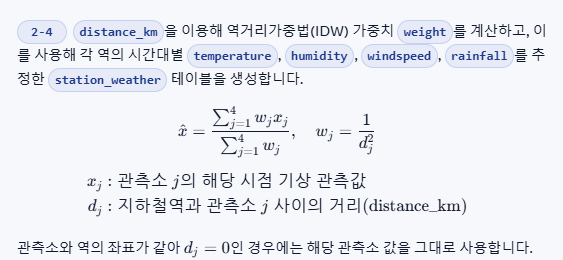

In [132]:
distance['weight'] = 1 / (distance['distance_km'] ** 2)

# Merge 
distance_weather = w.merge(distance, how = 'left' , left_on = 'site', right_on = '관측소')
distance_weather

cols = ['temperature','humidity', 'windspeed', 'rainfall']

for col in cols : 
    distance_weather[f'{col}_2'] = (distance_weather[col] * distance_weather['weight'] )

# 역의 시간대별 Σ(wx), Σ(w)
result  = distance_weather.groupby(['역','datetime'])[[f'{c}_2' for c in cols] + ['weight']].sum().reset_index()

# 계산된 값을 원래 Col로 
for col in cols : 
    result[col] = result[f'{col}_2'] / result['weight']

# 최종
station_weather = result[['역','datetime'] + cols]
station_weather['datetime'] = pd.to_datetime(station_weather['datetime'])

C:\Users\user\AppData\Local\Temp\ipykernel_19904\3523794586.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  station_weather['datetime'] = pd.to_datetime(station_weather['datetime'])


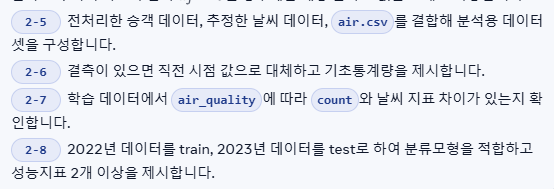

In [133]:
a= pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/air.csv')
a.head()
a['datetime'] = pd.to_datetime(a['datetime'])

In [134]:
t1 = pivot_df[['date','station','count']].sort_values(by = ['station','date'] , ascending = (True, True))
t2 = station_weather.copy()
t3 = a.copy()

In [149]:
# t2 -> datetime으로 바꿔야함 
m1 = t1.merge(t2, how = 'left' , left_on = ['date','station'], right_on = ['datetime','역']).drop(columns = ['역','datetime'])
m2 = m1.merge(t3, how = 'left', left_on = 'date', right_on = 'datetime').drop(columns = 'datetime')

# 최종 데이터 셋
m2.head()

,date,station,count,temperature,humidity,windspeed,rainfall,air_quality
0,2022-01-01 05:00:00,강남역,561.0,-9.183142,52.494601,3.602886,0.0,1
1,2022-01-01 06:00:00,강남역,1577.0,-9.047619,51.267481,2.273523,0.0,1
2,2022-01-01 07:00:00,강남역,1634.0,-8.864466,49.465274,1.146480,0.0,1
3,2022-01-01 08:00:00,강남역,3690.0,-8.702921,48.058654,2.657916,0.0,1
4,2022-01-01 09:00:00,강남역,7703.0,-9.306957,54.831534,6.102183,0.0,1


In [150]:
# m2.isna().sum() -> count : 240 
# 직전값으로 채우기 (ffill)
m2['count'].fillna(method = 'ffill', inplace = True)

C:\Users\user\AppData\Local\Temp\ipykernel_19904\4189647109.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  m2['count'].fillna(method = 'ffill', inplace = True)


In [151]:
# 기초 통계량 
m2.describe()

,date,count,temperature,humidity,windspeed,rainfall,air_quality
count,97090,97090.000000,97090.000000,97090.000000,97090.000000,97090.000000,97090.000000
mean,2023-01-01 01:59:59.999999744,4776.340406,12.460336,68.204191,9.561445,0.182948,0.500000
min,2022-01-01 05:00:00,19.000000,-18.599444,0.147298,0.007729,0.000000,0.000000
25%,2022-07-02 14:00:00,1755.000000,3.320743,52.436507,5.494296,0.000000,0.000000
50%,2023-01-01 02:00:00,3586.000000,13.813257,70.568199,8.141701,0.000000,0.500000
75%,2023-07-02 14:00:00,6704.000000,22.401551,86.403461,12.725020,0.000000,1.000000
max,2023-12-31 23:00:00,27041.000000,34.796272,100.000000,41.776999,22.265948,1.000000
std,NaN,4061.818697,11.216411,20.768826,5.547690,0.862881,0.500003


In [156]:
# 학습 데이터에서 air_quality에 따라 count와 날씨 지표의 차이 
#m2['air_quality'].value_counts() # 1.0 
cols = ['count', 'temperature', 'humidity', 'windspeed',  'rainfall']

res = []
for col in cols : 
    g = m2.groupby('air_quality')[col].apply(list)
    s, p = stats.ttest_ind(g[0], g[1])
    d = '차이가 있다' if p < 0.05 else '차이가 없다'
    res.append([col, p, d]) 

print(pd.DataFrame(res))

             0              1       2
0        count   0.000000e+00  차이가 있다
1  temperature  1.742490e-156  차이가 있다
2     humidity  2.661193e-116  차이가 있다
3    windspeed   0.000000e+00  차이가 있다
4     rainfall   0.000000e+00  차이가 있다


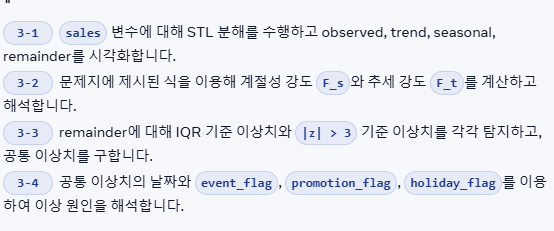

In [157]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/sales_stl.csv')
df.head()

,date,sales,event_flag,promotion_flag,holiday_flag
0,2022-01-01,227.58,0,0,1
1,2022-01-02,191.47,0,0,0
2,2022-01-03,173.23,0,0,0
3,2022-01-04,175.82,0,0,0
4,2022-01-05,181.92,0,0,0


In [161]:
# 시계열 데이터 반드시 처리해주기
df['date'] =pd.to_datetime(df['date'])
df = df.set_index(df['date'])

In [165]:
from statsmodels.tsa.seasonal import STL 
st = STL(df['sales'], period = 7, robust = True)
res = st.fit()

df['r'] = res.resid
df['t'] = res.trend
df['s'] = res.seasonal
df['o'] = res.observed 

df.head()

,date,sales,event_flag,promotion_flag,holiday_flag,r,t,s,o
date,,,,,,,,,
2022-01-01,2022-01-01,227.58,0,0,1,0.867896,192.360223,34.351880,227.58
2022-01-02,2022-01-02,191.47,0,0,0,-0.419566,191.983266,-0.093700,191.47
2022-01-03,2022-01-03,173.23,0,0,0,-0.616479,191.607307,-17.760827,173.23
2022-01-04,2022-01-04,175.82,0,0,0,0.311748,191.228143,-15.719890,175.82
2022-01-05,2022-01-05,181.92,0,0,0,-0.836656,190.843062,-8.086405,181.92


In [167]:
# Fs 
# 1 - (Var(Reminder) / Var(seasonal + remainder))
Fs = 1 - (np.var(df['r']) / np.var(df['s'] + df['r']))
Ft = 1 - (np.var(df['r']) / np.var(df['t'] + df['r']))

print(Fs, Ft)
print('''
해석 
0에 가까움 : 영향없음
1에 가까움 : 영향 매우 큼
''')

0.7392376498480607 0.8620235976723922

해석 
0에 가까움 : 영향없음
1에 가까움 : 영향 매우 큼



3-3 Reminder에 대한 IQR기반, Z-score기반

In [175]:
# IQR
q3 = df['r'].quantile(0.75)
q1 = df['r'].quantile(0.25)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df['iqr_mask'] = (df['r'] > upper) | (df['r'] < lower) 

In [179]:
# Z-score
df['z_score_mask'] = ((df['r'] - df['r'].mean()) / df['r'].std() > 3 ) 

In [189]:
# 공통 이상치
common_mask  = ((df['iqr_mask'] == True) & (df['z_score_mask'] == True))
print(df[common_mask][['date','sales','event_flag','promotion_flag', 'holiday_flag']])
print('''
공통 이상치를 통해 발견된 내용은 holiday_flag(휴일) 구간에서 발생하며, 매출에 영향을 미치는 것으로 확인된다. 
이상치는 “공휴일 영향 > 프로모션 영향 > 이벤트 영향 없음”
''')

                 date   sales  event_flag  promotion_flag  holiday_flag
date                                                                   
2022-02-01 2022-02-01  258.77           0               0             1
2022-09-10 2022-09-10  322.42           0               0             1
2022-11-11 2022-11-11  297.66           0               1             0
2023-01-22 2023-01-22  315.51           0               0             1
2023-05-05 2023-05-05  318.80           0               1             0
2023-09-29 2023-09-29  355.60           0               0             1

공통 이상치를 통해 발견된 내용은 holiday_flag(휴일) 구간에서 발생하며, 매출에 영향을 미치는 것으로 확인된다. 
이상치는 “공휴일 영향 > 프로모션 영향 > 이벤트 영향 없음”



##### 4. 
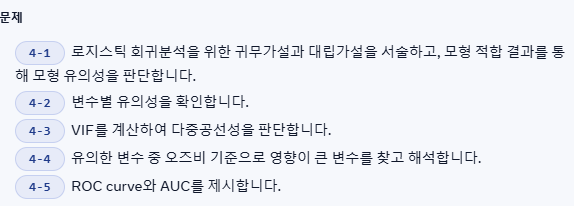

In [223]:
df = pd.read_csv('https://raw.githubusercontent.com/doeungim/ADP_2026/refs/heads/main/ADP_DATA/35_DATA/Telecom.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [224]:
# 전처리 
df2 = df.drop(columns = 'customerID', axis = 1)

m_df = pd.DataFrame()
for col in df2.columns : 
    if df2[col].dtypes == 'object' : 
        m_df[col] = LabelEncoder().fit_transform(df2[col])

    else : 
        m_df[col] = df2[col]
m_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


In [251]:
# 4-1 
# 귀무가설 : 회귀계수는 0이다
# 대립가설 : 적어도 하나의 회귀계수는 0이 아니다. 

X = m_df.drop('Churn', axis = 1)
y = m_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

add_x = sm.add_constant(X_train)
model = sm.Logit(y_train, add_x)
res = model.fit()

summary = pd.DataFrame(res.summary().tables[1].data)
summary.columns = summary.iloc[0]

summary['d'] = pd.to_numeric(summary['P>|z|'] , errors = 'coerce').\
                apply(lambda x : '유의하다' if x < 0.05 else '유의하지않다')
summary

Optimization terminated successfully.
         Current function value: 0.414864
         Iterations 7


,,coef,std err,z,P>|z|,[0.025,0.975],d
0,,coef,std err,z,P>|z|,[0.025,0.975],유의하지않다
1,const,-1.2867,0.178,-7.215,0.000,-1.636,-0.937,유의하다
2,gender,0.0134,0.073,0.185,0.853,-0.129,0.156,유의하지않다
3,SeniorCitizen,0.1714,0.094,1.816,0.069,-0.014,0.356,유의하지않다
4,Partner,0.0426,0.086,0.493,0.622,-0.127,0.212,유의하지않다
5,Dependents,-0.2465,0.100,-2.458,0.014,-0.443,-0.050,유의하다
6,tenure,-0.0336,0.003,-12.703,0.000,-0.039,-0.028,유의하다
7,PhoneService,-0.9530,0.160,-5.939,0.000,-1.268,-0.638,유의하다
8,MultipleLines,0.1073,0.046,2.354,0.019,0.018,0.197,유의하다
9,InternetService,0.2568,0.073,3.533,0.000,0.114,0.399,유의하다


In [252]:
# 4-3 다중공선성
X = m_df[vif_col]

vif = pd.DataFrame(
    {'변수' : X.columns, 
     'VIF' : [variance_inflation_factor(m_df[vif_col].values, i) for i in range(m_df[vif_col].shape[1])]        
    }
)
vif 
print('''
VIF를 통해 다중공선성을 확인한 결과, 모든 변수의 VIF 값이 10 미만으로 나타나 다중공선성 문제는 없는 것으로 판단된다. 
따라서 변수 간 독립성이 확보되어 회귀계수의 안정적인 추정이 가능하다.
''')


VIF를 통해 다중공선성을 확인한 결과, 모든 변수의 VIF 값이 10 미만으로 나타나 다중공선성 문제는 없는 것으로 판단된다. 
따라서 변수 간 독립성이 확보되어 회귀계수의 안정적인 추정이 가능하다.



In [260]:
# 4-4 유의한 변수 중 Odds비 기준으로 영향도가 높은 변수를 찾기 - np.exp(coef) : Odds비 
summary['coef'] = pd.to_numeric(summary['coef'], errors = 'coerce')
summary['odds']  = np.exp(summary['coef'])
summary['odds_decision'] = (summary['odds'] - 1).abs()
display(summary[summary['d'] == '유의하다'].sort_values('odds_decision', ascending = False))
print('''
유의한 변수 중 Odds Ratio를 기준으로 영향도를 분석한 결과, PaperlessBilling은 가장 큰 증가 영향을 미치는 변수이며, 
PhoneService는 가장 큰 감소 영향을 미치는 변수로 나타났다.

''')

,,coef,std err,z,P>|z|,[0.025,0.975],d,odds,odds_decition,odds_decision
1,const,-1.286700,0.178,-7.215,0.000,-1.636,-0.937,유의하다,0.276181,-0.723819,0.723819
7,PhoneService,-0.953000,0.160,-5.939,0.000,-1.268,-0.638,유의하다,0.385583,-0.614417,0.614417
16,Contract,-0.743700,0.086,-8.635,0.000,-0.912,-0.575,유의하다,0.475352,-0.524648,0.524648
17,PaperlessBilling,0.385600,0.083,4.642,0.000,0.223,0.548,유의하다,1.470496,0.470496,0.470496
9,InternetService,0.256800,0.073,3.533,0.000,0.114,0.399,유의하다,1.292787,0.292787,0.292787
10,OnlineSecurity,-0.275900,0.046,-5.949,0.000,-0.367,-0.185,유의하다,0.758889,-0.241111,0.241111
13,TechSupport,-0.252700,0.047,-5.374,0.000,-0.345,-0.161,유의하다,0.776701,-0.223299,0.223299
5,Dependents,-0.246500,0.100,-2.458,0.014,-0.443,-0.050,유의하다,0.781531,-0.218469,0.218469
11,OnlineBackup,-0.135700,0.042,-3.197,0.001,-0.219,-0.052,유의하다,0.873105,-0.126895,0.126895
8,MultipleLines,0.107300,0.046,2.354,0.019,0.018,0.197,유의하다,1.113268,0.113268,0.113268



유의한 변수 중 Odds Ratio를 기준으로 영향도를 분석한 결과, PaperlessBilling은 가장 큰 증가 영향을 미치는 변수이며, 
PhoneService는 가장 큰 감소 영향을 미치는 변수로 나타났다.




Optimization terminated successfully.
         Current function value: 0.414864
         Iterations 7


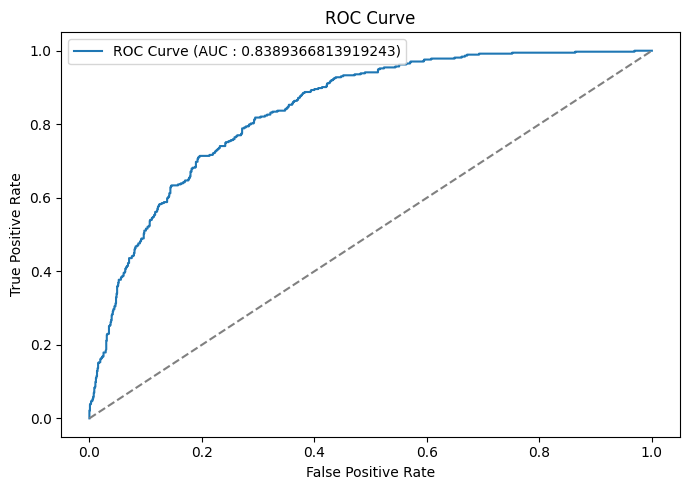

In [263]:
## ROC Curve + AUC 
X = m_df.drop('Churn', axis = 1)
y = m_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

add_x = sm.add_constant(X_train)
model = sm.Logit(y_train, add_x)
res = model.fit()

# 주의
x_test_sm = sm.add_constant(X_test)
y_prob = res.predict(x_test_sm)

fpr, tpr , _ = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)

plt.figure(figsize = (7,5)) 
plt.plot(fpr, tpr, label = F'ROC Curve (AUC : {auc_score})') 
plt.plot([0,1], [0,1], color = 'gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()
